# Convolutional Neural Networks: companion notebook

This notebook accompanies `lecture_notes/20_convnets.pdf`. It is organized around the same ideas as the notes, but focuses on executable checks, tensor shapes, and small experiments.

Use it while reading the notes:

- Sections 1-2: why CNNs are different from MLPs, and how convolution works.
- Section 3: pooling and downsampling.
- Sections 4-6: LeNet-style CNNs, PyTorch implementation, and training mechanics.
- Sections 7-10: debugging, modern architectures, residual connections, and summary.

## 0. Setup

The notebook uses only local arrays and local images by default. The optional MNIST section is written so that it can be skipped when `torchvision` or network access is unavailable.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Make examples deterministic.
torch.manual_seed(0)
np.random.seed(0)

# Find the repository root from the notebook location or current working directory.
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "lecture_notes" / "20_convnets.pdf").exists():
            return path
    return start

PROJECT_ROOT = find_project_root()
IMG_DIR = PROJECT_ROOT / "img"
print("Project root:", PROJECT_ROOT)

Project root: /home/ebezerra/ailab/cic1205


## 1. Why not just use an MLP for images?

Lecture notes, Section 1.

An MLP applied directly to pixels ignores spatial structure and uses a separate parameter for every input-to-hidden connection. A CNN uses three inductive biases that fit image data:

- **Local connectivity:** a neuron sees a small local region.
- **Parameter sharing:** the same kernel is reused at every spatial position.
- **Translation equivariance:** shifting an input shifts the corresponding feature map activation.

The parameter-count difference is often the first concrete reason CNNs are preferable for images.

In [2]:
def mlp_first_layer_params(height, width, channels, hidden_units, bias=True):
    weights = height * width * channels * hidden_units
    return weights + (hidden_units if bias else 0)


def conv2d_params(in_channels, out_channels, kernel_size, bias=True):
    weights = out_channels * in_channels * kernel_size * kernel_size
    return weights + (out_channels if bias else 0)

examples = [
    (32, 32, 1, 512, 32, 3),
    (32, 32, 3, 512, 32, 3),
    (224, 224, 3, 512, 64, 3),
]

for h, w, c, hidden, filters, k in examples:
    mlp_params = mlp_first_layer_params(h, w, c, hidden)
    cnn_params = conv2d_params(c, filters, k)
    print(f"Input {c}x{h}x{w}")
    print(f"  MLP first layer ({hidden} hidden units): {mlp_params:,} parameters")
    print(f"  Conv2d ({filters} filters, {k}x{k}):       {cnn_params:,} parameters")
    print(f"  Ratio MLP/CNN: {mlp_params / cnn_params:,.1f}x\n")

Input 1x32x32
  MLP first layer (512 hidden units): 524,800 parameters
  Conv2d (32 filters, 3x3):       320 parameters
  Ratio MLP/CNN: 1,640.0x

Input 3x32x32
  MLP first layer (512 hidden units): 1,573,376 parameters
  Conv2d (32 filters, 3x3):       896 parameters
  Ratio MLP/CNN: 1,756.0x

Input 3x224x224
  MLP first layer (512 hidden units): 77,070,848 parameters
  Conv2d (64 filters, 3x3):       1,792 parameters
  Ratio MLP/CNN: 43,008.3x



## 2. The convolution operation

Lecture notes, Sections 2.1-2.2.

Deep learning libraries call the operation a convolution, but implement **cross-correlation**: the kernel is not flipped. Since kernels are learned, the distinction is not important for CNN training.

For a single-channel input `X` and kernel `K`, each output value is the dot product between `K` and one local window of `X`, plus a bias.

In [3]:
def conv2d_numpy(x, kernel, bias=0.0, stride=1, padding=0):
    # Single-channel 2D cross-correlation with square or rectangular kernels.
    x = np.asarray(x, dtype=float)
    kernel = np.asarray(kernel, dtype=float)

    if padding > 0:
        x = np.pad(x, pad_width=padding, mode="constant", constant_values=0)

    kh, kw = kernel.shape
    h, w = x.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    out = np.zeros((out_h, out_w), dtype=float)

    for i in range(out_h):
        for j in range(out_w):
            row = i * stride
            col = j * stride
            window = x[row:row + kh, col:col + kw]
            out[i, j] = np.sum(window * kernel) + bias
    return out

X = np.array([
    [1, 2, 0, 1],
    [0, 1, 3, 2],
    [2, 0, 1, 1],
    [1, 3, 2, 0],
])

K = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
])

Z = conv2d_numpy(X, K, stride=1, padding=0)
print(Z)

[[-1. -1.]
 [-3.  1.]]


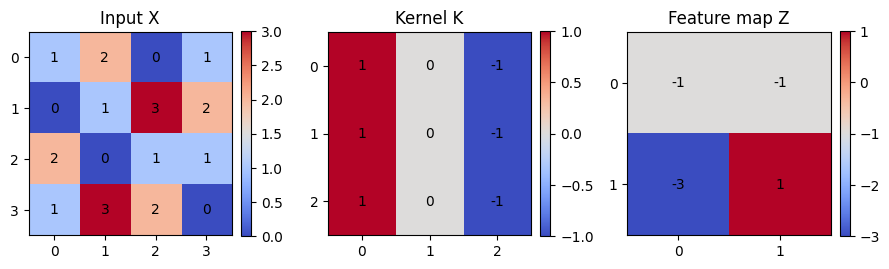

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, data, title in zip(axes, [X, K, Z], ["Input X", "Kernel K", "Feature map Z"]):
    im = ax.imshow(data, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks(range(data.shape[1]))
    ax.set_yticks(range(data.shape[0]))
    for (i, j), value in np.ndenumerate(data):
        ax.text(j, i, f"{value:g}", ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

### Padding and stride

Lecture notes, Section 2.3.

For input size `H`, kernel size `k`, padding `p`, and stride `s`, the spatial output size is:

$$
H_{out} = \left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1
$$

The same formula applies to width.

In [5]:
def output_size(size, kernel_size, padding=0, stride=1):
    return (size + 2 * padding - kernel_size) // stride + 1

settings = [
    (32, 3, 0, 1),
    (32, 3, 1, 1),
    (32, 3, 0, 2),
    (32, 5, 2, 1),
    (32, 7, 3, 2),
]

print("Input  Kernel  Padding  Stride  Output")
for size, k, p, s in settings:
    print(f"{size:>5} {k:>7} {p:>8} {s:>7} {output_size(size, k, p, s):>7}")

Input  Kernel  Padding  Stride  Output
   32       3        0       1      30
   32       3        1       1      32
   32       3        0       2      15
   32       5        2       1      32
   32       7        3       2      16


### NumPy and PyTorch compute the same cross-correlation

Lecture notes, Sections 2.1-2.4.

PyTorch expects 4D tensors for `nn.Conv2d`: `(N, C_in, H, W)`, where `N` is the batch size.

In [6]:
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=0, bias=True)

with torch.no_grad():
    conv.weight.copy_(torch.tensor(K, dtype=torch.float32).view(1, 1, 3, 3))
    conv.bias.zero_()

torch_input = torch.tensor(X, dtype=torch.float32).view(1, 1, 4, 4)
torch_output = conv(torch_input)

print("Input shape: ", tuple(torch_input.shape))
print("Weight shape:", tuple(conv.weight.shape))
print("Output shape:", tuple(torch_output.shape))
print(torch_output.squeeze().detach().numpy())

np.testing.assert_allclose(Z, torch_output.squeeze().detach().numpy())

Input shape:  (1, 1, 4, 4)
Weight shape: (1, 1, 3, 3)
Output shape: (1, 1, 2, 2)
[[-1. -1.]
 [-3.  1.]]


### Channels: depth in convolutional layers

Lecture notes, Section 2.4.

A convolutional layer with `C_in` input channels, `C_out` output channels, and a `k x k` kernel has:

$$
C_{out} \times (C_{in} \times k \times k + 1)
$$

learnable parameters when bias is enabled.

In [7]:
batch = torch.randn(8, 3, 32, 32)          # N, C_in, H, W
layer = nn.Conv2d(3, 64, kernel_size=3, padding=1)
out = layer(batch)

manual_count = conv2d_params(in_channels=3, out_channels=64, kernel_size=3, bias=True)
torch_count = sum(p.numel() for p in layer.parameters())

print("Input shape: ", tuple(batch.shape))
print("Weight shape:", tuple(layer.weight.shape))
print("Output shape:", tuple(out.shape))
print("Manual parameter count:", manual_count)
print("PyTorch parameter count:", torch_count)

Input shape:  (8, 3, 32, 32)
Weight shape: (64, 3, 3, 3)
Output shape: (8, 64, 32, 32)
Manual parameter count: 1792
PyTorch parameter count: 1792


## 3. Pooling layers

Lecture notes, Section 3.

Pooling reduces spatial dimensions without learnable parameters. It does **not** change the number of channels.

In [8]:
pool_input = torch.tensor([
    [3, 1, 2, 4],
    [0, 5, 1, 2],
    [2, 3, 0, 1],
    [1, 0, 4, 3],
], dtype=torch.float32).view(1, 1, 4, 4)

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

print("Max pooling:")
print(max_pool(pool_input).squeeze().numpy())
print("\nAverage pooling:")
print(avg_pool(pool_input).squeeze().numpy())

Max pooling:
[[5. 4.]
 [3. 4.]]

Average pooling:
[[2.25 2.25]
 [1.5  2.  ]]


In [9]:
three_channel_input = torch.randn(1, 16, 28, 28)
pooled = nn.MaxPool2d(kernel_size=2, stride=2)(three_channel_input)
print("Before pooling:", tuple(three_channel_input.shape))
print("After pooling: ", tuple(pooled.shape))

Before pooling: (1, 16, 28, 28)
After pooling:  (1, 16, 14, 14)


## 4. Hand-crafted filters as intuition for learned kernels

Lecture notes, Sections 2 and 7.3.

CNN kernels are learned by backpropagation, not manually supplied. Still, classical filters such as Prewitt are useful for building intuition: a small matrix can detect edges when it is applied across an image.

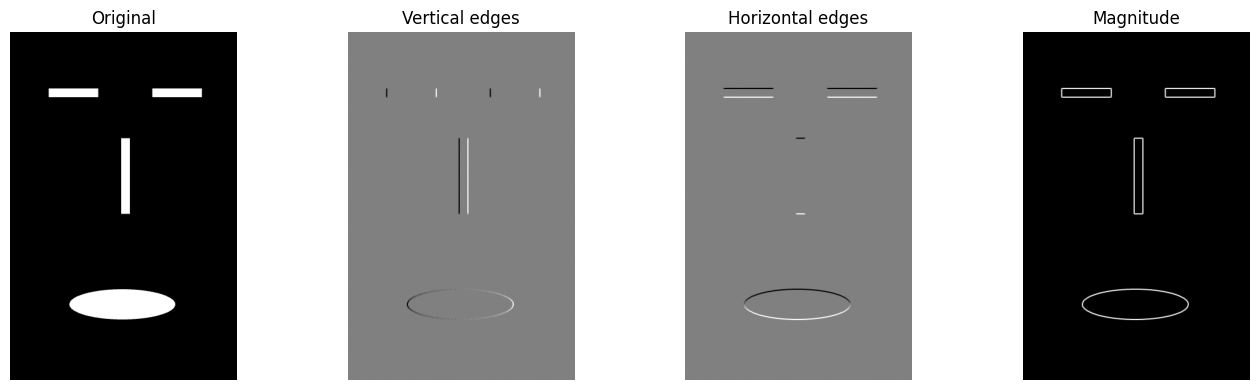

In [10]:
def load_grayscale_image(path):
    image = plt.imread(path)
    if image.dtype.kind in "ui":
        image = image.astype(np.float32) / 255.0
    if image.ndim == 3:
        image = image[..., :3].mean(axis=2)
    return image.astype(np.float32)

image_path = IMG_DIR / "mocked_face.png"
image = load_grayscale_image(image_path)

prewitt_v = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
], dtype=np.float32)

prewitt_h = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1],
], dtype=np.float32)

image_tensor = torch.tensor(image).view(1, 1, image.shape[0], image.shape[1])
kernels = torch.tensor(np.stack([prewitt_v, prewitt_h])).view(2, 1, 3, 3)

with torch.no_grad():
    edges = F.conv2d(image_tensor, kernels, padding=1).squeeze().numpy()
edge_magnitude = np.sqrt(edges[0] ** 2 + edges[1] ** 2)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, data, title in zip(
    axes,
    [image, edges[0], edges[1], edge_magnitude],
    ["Original", "Vertical edges", "Horizontal edges", "Magnitude"],
):
    ax.imshow(data, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

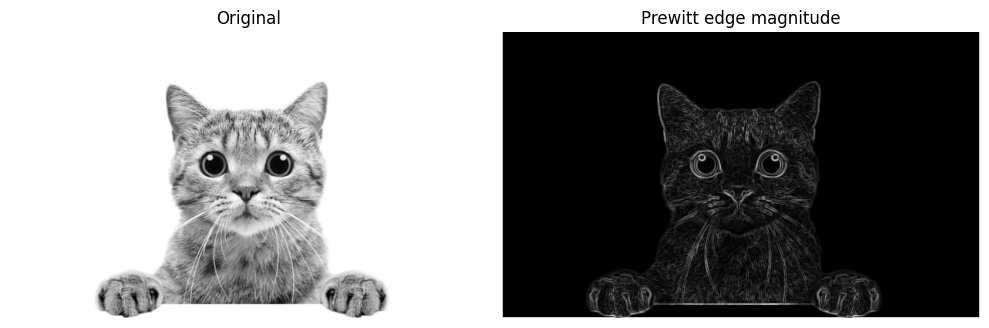

In [11]:
cat_path = IMG_DIR / "cute_cat.jpeg"
if cat_path.exists():
    cat = load_grayscale_image(cat_path)
    cat_tensor = torch.tensor(cat).view(1, 1, cat.shape[0], cat.shape[1])
    with torch.no_grad():
        cat_edges = F.conv2d(cat_tensor, kernels, padding=1).squeeze().numpy()
    cat_edge_magnitude = np.sqrt(cat_edges[0] ** 2 + cat_edges[1] ** 2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(cat, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(cat_edge_magnitude, cmap="gray")
    axes[1].set_title("Prewitt edge magnitude")
    axes[1].axis("off")
    plt.tight_layout()
else:
    print("Local cat image not found:", cat_path)

## 5. CNN architecture: a LeNet-style model

Lecture notes, Section 4.

A common CNN pattern is:

`Conv2d -> BatchNorm2d -> ReLU -> Pool -> ... -> Flatten -> Linear layers`

The spatial dimensions usually decrease while the channel depth increases.

In [12]:
class LeNetCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),   # (1, 28, 28) -> (6, 28, 28)
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # (6, 28, 28) -> (6, 14, 14)
            nn.Conv2d(6, 16, kernel_size=5),             # (6, 14, 14) -> (16, 10, 10)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # (16, 10, 10) -> (16, 5, 5)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes),                  # logits
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = LeNetCNN(num_classes=10)
print(model)

LeNetCNN(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=120, out_features=84, bias=True)
    (5): ReLU()
    (6): Linear(in_features=84, out_features=10, bias=True)
  )
)


In [13]:
def trace_shapes(model, x):
    print("input", tuple(x.shape))
    for name, module in model.features.named_children():
        x = module(x)
        print(f"features[{name}] {module.__class__.__name__:>12}: {tuple(x.shape)}")
    for name, module in model.classifier.named_children():
        x = module(x)
        print(f"classifier[{name}] {module.__class__.__name__:>10}: {tuple(x.shape)}")
    return x

dummy = torch.randn(4, 1, 28, 28)
logits = trace_shapes(model, dummy)
print("\nFinal logits shape:", tuple(logits.shape))

input (4, 1, 28, 28)
features[0]       Conv2d: (4, 6, 28, 28)
features[1]  BatchNorm2d: (4, 6, 28, 28)
features[2]         ReLU: (4, 6, 28, 28)
features[3]    MaxPool2d: (4, 6, 14, 14)
features[4]       Conv2d: (4, 16, 10, 10)
features[5]  BatchNorm2d: (4, 16, 10, 10)
features[6]         ReLU: (4, 16, 10, 10)
features[7]    MaxPool2d: (4, 16, 5, 5)
classifier[0]    Flatten: (4, 400)
classifier[1]     Linear: (4, 120)
classifier[2]       ReLU: (4, 120)
classifier[3]    Dropout: (4, 120)
classifier[4]     Linear: (4, 84)
classifier[5]       ReLU: (4, 84)
classifier[6]     Linear: (4, 10)

Final logits shape: (4, 10)


In [14]:
def parameter_table(model):
    rows = []
    total = 0
    for name, parameter in model.named_parameters():
        count = parameter.numel()
        total += count
        rows.append((name, tuple(parameter.shape), count))
    return rows, total

rows, total = parameter_table(model)
for name, shape, count in rows:
    print(f"{name:28s} {str(shape):18s} {count:8,d}")
print(f"{'TOTAL':28s} {'':18s} {total:8,d}")

features.0.weight            (6, 1, 5, 5)            150
features.0.bias              (6,)                      6
features.1.weight            (6,)                      6
features.1.bias              (6,)                      6
features.4.weight            (16, 6, 5, 5)         2,400
features.4.bias              (16,)                    16
features.5.weight            (16,)                    16
features.5.bias              (16,)                    16
classifier.1.weight          (120, 400)           48,000
classifier.1.bias            (120,)                  120
classifier.4.weight          (84, 120)            10,080
classifier.4.bias            (84,)                    84
classifier.6.weight          (10, 84)                840
classifier.6.bias            (10,)                    10
TOTAL                                             61,750


### Logits, softmax, and cross-entropy

Lecture notes, Section 6.1.

`nn.CrossEntropyLoss` expects raw logits. Do not add `Softmax` as the final layer during training.

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

images = torch.randn(8, 1, 28, 28)
labels = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7])

model.train()
optimizer.zero_grad()
logits = model(images)
loss = criterion(logits, labels)
loss.backward()
optimizer.step()

print("Logits shape:", tuple(logits.shape))
print("One training-step loss:", float(loss.detach()))

Logits shape: (8, 10)
One training-step loss: 2.3372817039489746


### Optional MNIST data pipeline

Lecture notes, Section 6.2.

This cell is optional because it may download data. It also demonstrates an important rule: augmentation belongs in the training transform, not the validation/test transform.

In [16]:
try:
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader

    train_transform = transforms.Compose([
        transforms.RandomCrop(28, padding=2),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.1307,), std=(0.3081,)),
    ])

    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.1307,), std=(0.3081,)),
    ])

    # Set download=True when you want to fetch MNIST.
    train_dataset = datasets.MNIST(root=PROJECT_ROOT / "data", train=True, download=False, transform=train_transform)
    val_dataset = datasets.MNIST(root=PROJECT_ROOT / "data", train=False, download=False, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
    print("MNIST loaders ready:", len(train_dataset), len(val_dataset))
except Exception as exc:
    print("Skipping optional MNIST setup:", exc)

MNIST loaders ready: 60000 10000


### Evaluation mode matters

Lecture notes, Sections 6.3 and 7.

`model.train()` activates dropout and uses batch statistics in batch normalization. `model.eval()` disables dropout and uses running batch-normalization statistics. Evaluation should normally use `model.eval()` and `torch.no_grad()`.

In [17]:
x = torch.randn(2, 1, 28, 28)

model.train()
y_train_1 = model(x)
y_train_2 = model(x)

model.eval()
with torch.no_grad():
    y_eval_1 = model(x)
    y_eval_2 = model(x)

print("Train-mode outputs equal?", torch.allclose(y_train_1, y_train_2))
print("Eval-mode outputs equal? ", torch.allclose(y_eval_1, y_eval_2))

Train-mode outputs equal? False
Eval-mode outputs equal?  True


## 6. Debugging checklist

Lecture notes, Section 7.

Use these checks before tuning hyperparameters:

- Print tensor shapes through the model.
- Overfit one tiny batch; the loss should approach zero.
- Confirm input normalization and channel order.
- Check `model.train()` during training and `model.eval()` during evaluation.
- Confirm that `CrossEntropyLoss` receives integer class labels, not one-hot vectors.
- Verify that `in_channels` matches the dataset: grayscale images use 1, RGB images use 3.

Initial loss: 2.387235164642334
Final loss:   0.06181112676858902


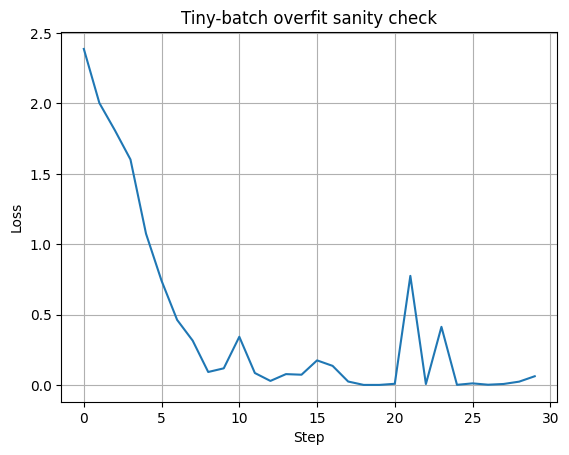

In [18]:
def can_overfit_tiny_batch(steps=50, lr=1e-2):
    tiny_x = torch.randn(8, 1, 28, 28)
    tiny_y = torch.arange(8) % 10
    tiny_model = LeNetCNN(num_classes=10)
    optimizer = torch.optim.Adam(tiny_model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    losses = []
    tiny_model.train()
    for _ in range(steps):
        optimizer.zero_grad()
        loss = criterion(tiny_model(tiny_x), tiny_y)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach()))
    return losses

losses = can_overfit_tiny_batch(steps=30)
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Tiny-batch overfit sanity check")
plt.grid(True)
print("Initial loss:", losses[0])
print("Final loss:  ", losses[-1])

## 7. Residual connections

Lecture notes, Section 8.2.

A residual block learns a correction `F(x)` and adds the original input back: `F(x) + x`. This gives gradients a direct path through the identity branch and makes identity-like transformations easy to represent.

In [19]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.activation = nn.ReLU()

    def forward(self, x):
        return self.activation(self.block(x) + x)

residual = ResidualBlock(channels=16)
res_input = torch.randn(4, 16, 10, 10)
res_output = residual(res_input)
print("Input shape: ", tuple(res_input.shape))
print("Output shape:", tuple(res_output.shape))

Input shape:  (4, 16, 10, 10)
Output shape: (4, 16, 10, 10)


## 8. Entry-ticket style exercises

These match the lecture notes' checkpoints.

1. For a `32 x 32 x 3` image and a first MLP hidden layer with 512 neurons, compute the number of weights. Compare it with a CNN layer with 32 filters of size `3 x 3`.
2. Given input shape `(16, 28, 28)`, 32 filters of size `3 x 3`, padding 1, and stride 1, compute the output shape and parameter count. Repeat for stride 2.
3. Verify every shape in the LeNet-style architecture using the output-size formula.
4. Explain why augmentation should be applied to training data but not validation/test data.
5. A CNN has high training accuracy and much lower validation accuracy. Name the phenomenon and list three interventions.
6. Explain why a CNN can be viewed as a structured MLP.

## 9. Key takeaways

- CNNs are efficient for images because they encode local connectivity and parameter sharing.
- Convolutional layers produce feature maps; the output shape depends on kernel size, padding, and stride.
- Pooling downsamples spatial dimensions but preserves the number of channels.
- In PyTorch, CNN inputs use shape `(N, C, H, W)`.
- `CrossEntropyLoss` expects logits, not probabilities.
- Batch normalization, data augmentation, transfer learning, and residual connections are standard tools for training deeper and more robust CNNs.